# End-to-End Exploratory Data Analysis (EDA) on the Titanic Dataset
### Day 1 Assignment
### Name: Divyashree R

The Titanic dataset contains passenger information such as age, gender, ticket class, fare, and survival status.

The goal of this analysis is to explore the dataset systematically, clean missing values, detect patterns, identify meaningful features, and uncover the key factors that influenced passenger survival.

This assignment is to perform exploratory data analysis on the Titanic dataset to understand patterns influencing passenger survival. The analysis includes data cleaning, feature engineering, statistical summaries, visualization, and automated profiling using ydata-profiling.

Google Colab Link: https://colab.research.google.com/drive/1izJHY9LeknvYQQnL-KBPw-z2RwX9GQo3?usp=sharing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="whitegrid")

In [2]:
!git clone 'https://github.com/HarshvardhanSingh-13/Datasets'

fatal: destination path 'Datasets' already exists and is not an empty directory.


In [3]:
df = pd.read_csv('/content/Datasets/Titanic_Dataset/Titanic-Dataset.csv')

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
print("Shape of dataset:", df.shape)
print("\nColumn Names:\n", df.columns)

Shape of dataset: (891, 12)

Column Names:
 Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [9]:
# Checking missing values in each column
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Calculating percentage of missing values
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
})

In [10]:
# Sorting from higher to lower values
missing_df.sort_values(by='Missing Values', ascending=False)

,Missing Values,Percentage (%)
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467
PassengerId,0,0.000000
Name,0,0.000000
Pclass,0,0.000000
Survived,0,0.000000
Sex,0,0.000000
Parch,0,0.000000
SibSp,0,0.000000


## Initial Observations

- The dataset contains 891 rows and 12 columns.
- The target variable is **Survived**, where:
  - 0 = Did Not Survive
  - 1 = Survived
- Missing values are observed in:
  - Age
  - Cabin (high percentage of missing values)
  - Embarked (very few missing values)
- Fare appears highly skewed based on summary statistics (maximum value significantly larger than mean).


In [11]:
# 1. Fill missing values in 'Age' using median
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)

# 2. Fill missing values in 'Embarked' using mode
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(mode_embarked)

# 3. Drop 'Cabin' column (too many missing values)
df = df.drop(columns=['Cabin'])

## Handling Missing Values
- Missing values in **Age** were filled using the median.
- Missing values in **Embarked** were filled using mode.
- The **Cabin** column was dropped due to more number of missing values.
- After these steps, the dataset contains no missing values.

In [12]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## Univariate Analysis – Categorical Features
Analyzing the categorical variables such as:

- Survived
- Pclass
- Sex
- Embarked

This helps us understand how passengers are distributed across different categories.

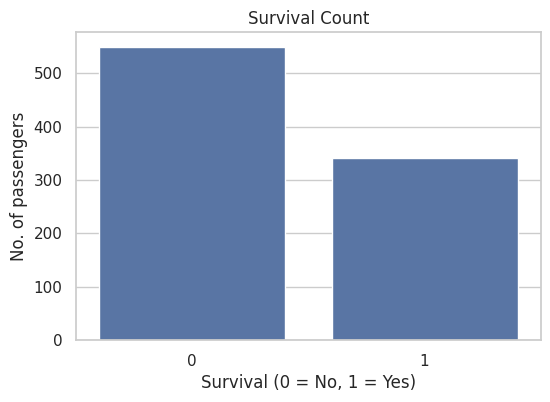

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)

plt.title("Survival Count")
plt.xlabel("Survival (0 = No, 1 = Yes)")
plt.ylabel("No. of passengers")
plt.show()

### Observations
- Majority of the passengers did not survive.
- Survival rate is approximately 38%.

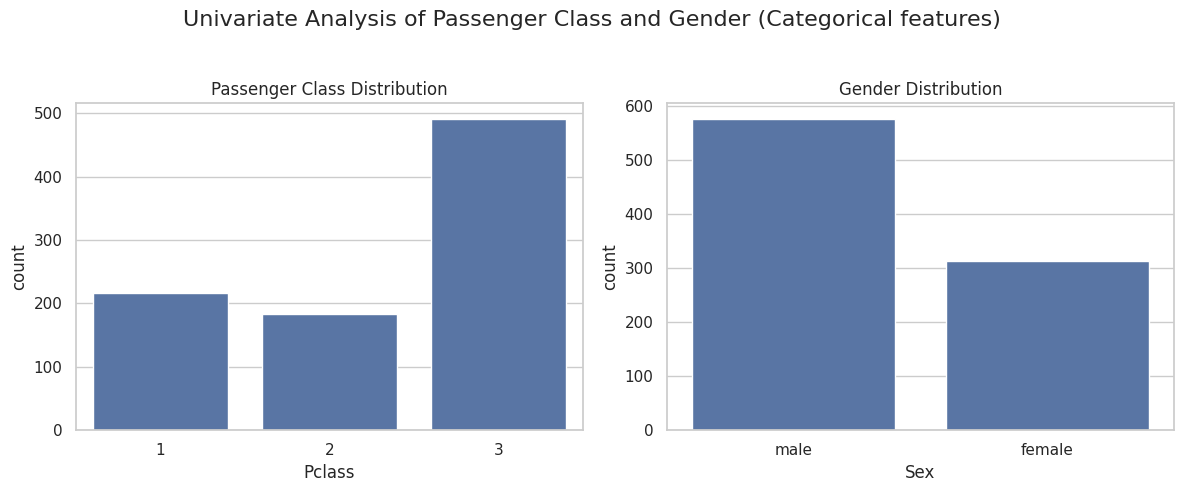

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Univariate Analysis of Passenger Class and Gender (Categorical features)", fontsize=16)

# Plotting
sns.countplot(ax=axes[0], x='Pclass', data=df).set_title("Passenger Class Distribution")
sns.countplot(ax=axes[1], x='Sex', data=df).set_title("Gender Distribution")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Observations
- Most passengers were from the 3rd class.
- Male passengers were higher in number compared to female passengers.


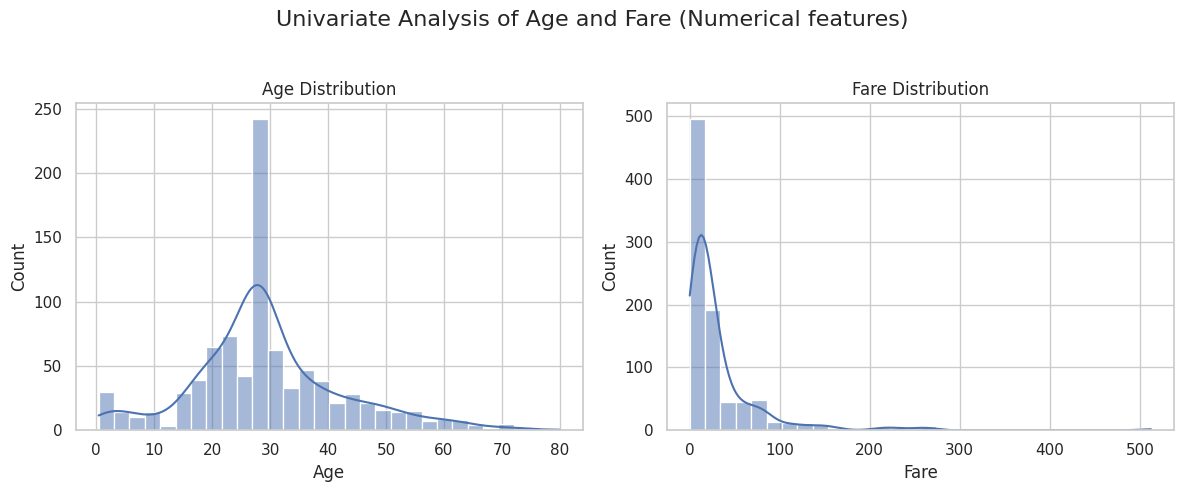

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Univariate Analysis of Age and Fare (Numerical features)", fontsize=16)

# Age Distribution
sns.histplot(ax=axes[0], x='Age', data=df, bins=30, kde=True).set_title("Age Distribution")

# Fare Distribution
sns.histplot(ax=axes[1], x='Fare', data=df, bins=30, kde=True).set_title("Fare Distribution")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [16]:
df[['Age', 'Fare']].skew()

,0
Age,0.510245
Fare,4.787317


### Observations

- The majority of passengers were between 20–40 years of age.
- The Fare distribution is highly right-skewed, indicating a small number of passengers paid higher fares.
- Age appears relatively normally distributed, while Fare shows strong positive skewness.

## Bivariate Analysis

Analyzing the relationship between two variables to understand how different features influence survival.

Finding survival rates across:

- Gender  
- Passenger Class  
- Port of Embarkation  

This helps identify the most influential factors affecting survival outcomes.

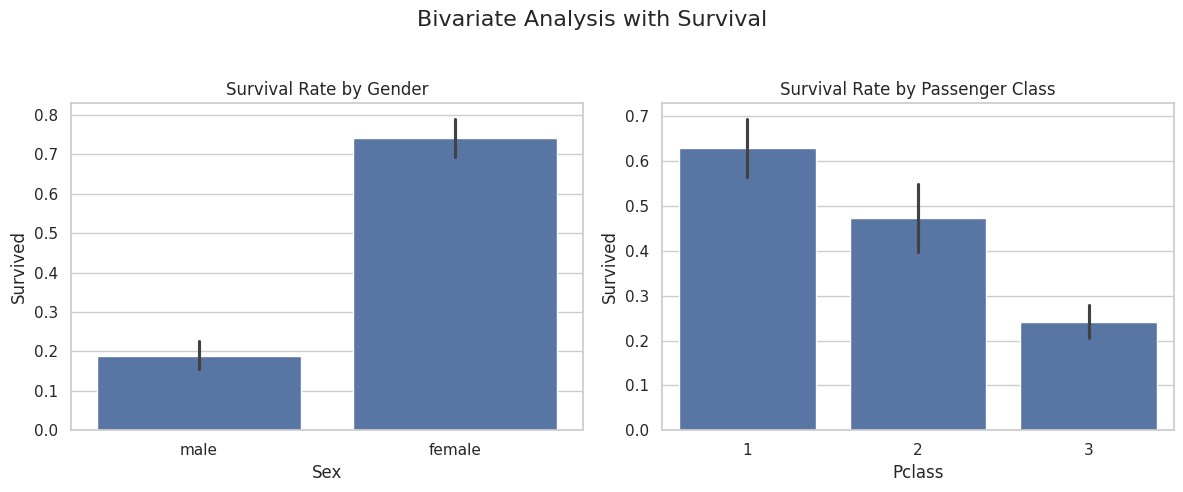

In [17]:
# Set up figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Bivariate Analysis with Survival", fontsize=16)

# Survival vs Gender
sns.barplot(ax=axes[0], x='Sex', y='Survived', data=df).set_title("Survival Rate by Gender")

# Survival vs Passenger Class
sns.barplot(ax=axes[1], x='Pclass', y='Survived', data=df).set_title("Survival Rate by Passenger Class")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Observations
- Female passengers had a significantly higher survival rate compared to male passengers.
- Survival probability decreases as passenger class increases (1st class had highest survival, 3rd class lowest).


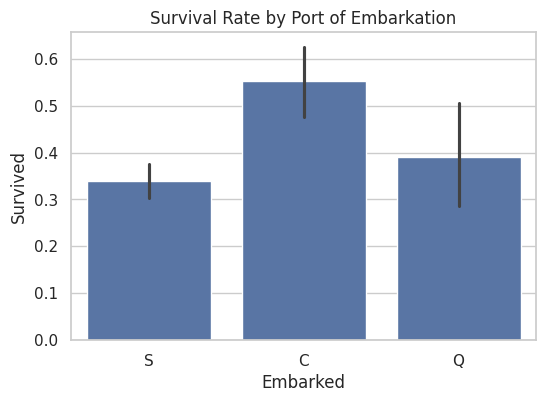

In [18]:
plt.figure(figsize=(6,4))
sns.barplot(x='Embarked', y='Survived', data=df).set_title("Survival Rate by Port of Embarkation")
plt.show()

### Observations

- Passengers embarking from certain ports show higher survival rates.
- Passengers embarking from Cherbourg(C) port had the highest survival rate.

## Multivariate Analysis

Analyzing the combined effect of multiple variables on survival.

Examining how survival rates vary when both passenger class and gender are considered together.


<Figure size 800x500 with 0 Axes>

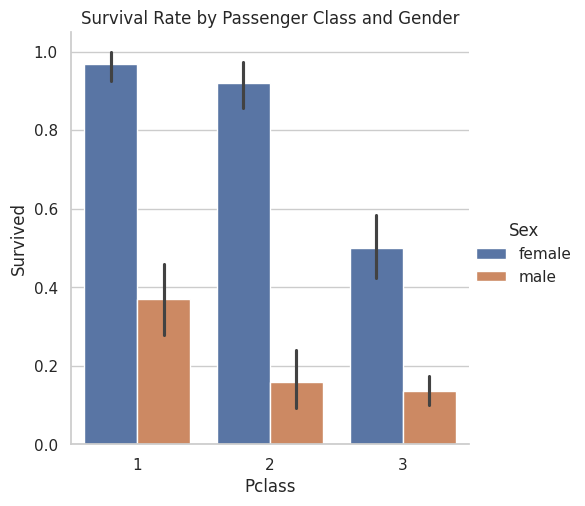

In [19]:
# Multivariate Survival Analysis
plt.figure(figsize=(8,5))
sns.catplot(x='Pclass', y='Survived', hue='Sex', kind='bar', data=df)

plt.title("Survival Rate by Passenger Class and Gender")
plt.show()

### Observations

- Across all passenger classes, females had higher survival rates than males.
- Even in third class, female survival was significantly higher than male survival.
- First-class females had the highest survival probability overall.
- This shows that gender was the most influential factor in survival.

## Feature Engineering
Creating new useful features from the existing data.

Here, we create:

- **FamilySize** - Total number of family members traveling together.
- **IsAlone** - Indicates whether the passenger was traveling alone or not.

These new features help us understand whether family size had any impact on survival.

In [20]:
# Creating FamilySize feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df[['SibSp', 'Parch', 'FamilySize']].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [21]:
# Creating IsAlone feature
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

df[['FamilySize', 'IsAlone']].head()

,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


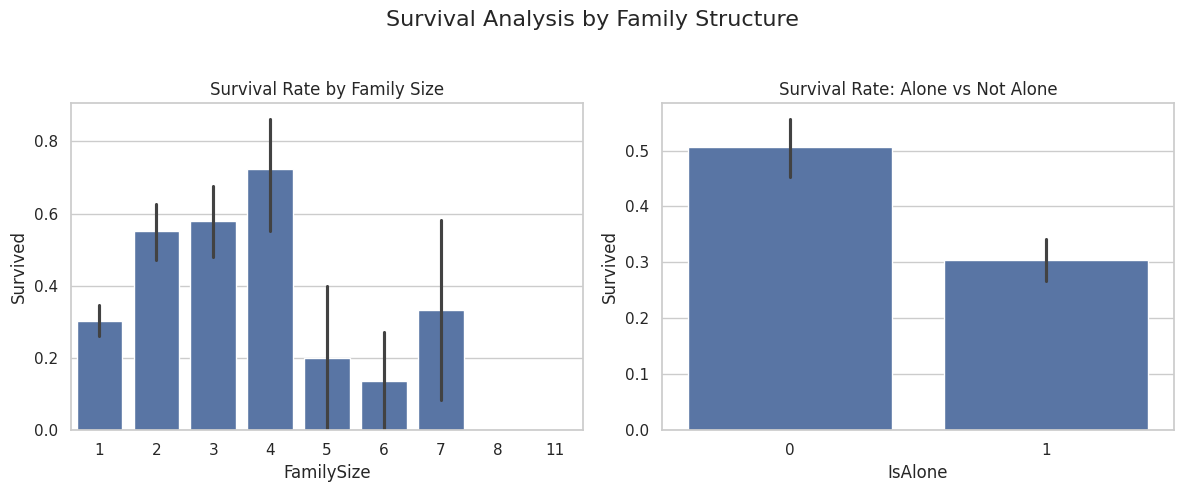

In [22]:
# Set up figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Survival Analysis by Family Structure", fontsize=16)

# Survival vs FamilySize
sns.barplot(ax=axes[0], x='FamilySize', y='Survived', data=df).set_title("Survival Rate by Family Size")

# Survival vs IsAlone
sns.barplot(ax=axes[1], x='IsAlone', y='Survived', data=df).set_title("Survival Rate: Alone vs Not Alone")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Observations

- Passengers traveling with small families appear to have better survival rates.
- Passengers traveling alone show slightly lower survival compared to small family groups.
- Very large family sizes seem to have reduced survival probability.

In [23]:
# Create AgeGroup feature
bins = [0, 12, 19, 59, 100]
labels = ['Child', 'Teen', 'Adult', 'Senior']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

df[['Age', 'AgeGroup']].head()

,Age,AgeGroup
0,22.0,Adult
1,38.0,Adult
2,26.0,Adult
3,35.0,Adult
4,35.0,Adult


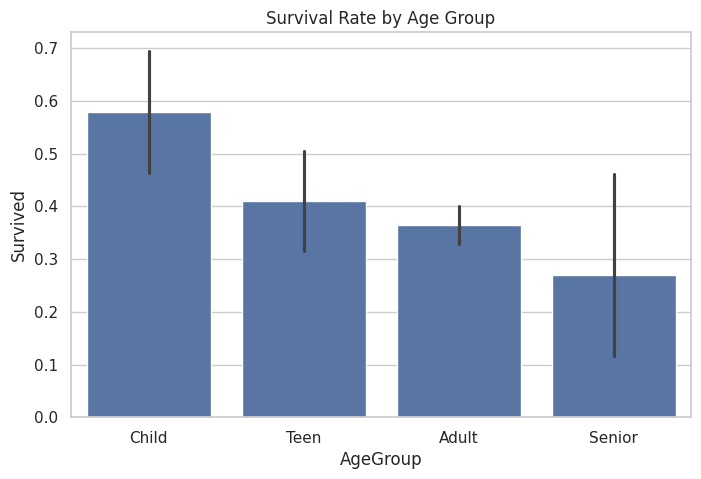

In [24]:
plt.figure(figsize=(8,5))
sns.barplot(x='AgeGroup', y='Survived', data=df)
plt.title("Survival Rate by Age Group")
plt.show()

### Observations

- Children show relatively higher survival rates compared to adults.
- Adults form the majority of passengers but have moderate survival rates.
- Senior passengers appear to have lower survival probability.


In [25]:
# Extract title from Name column using regex
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

df['Title'].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [26]:
# Group rare titles into 'Rare'
rare_titles = ['Dr', 'Rev', 'Col', 'Major', 'Mlle', 'Countess', 'Ms', 'Lady', 'Jonkheer', 'Don', 'Mme', 'Capt', 'Sir']

df['Title'] = df['Title'].replace(rare_titles, 'Rare')

df['Title'].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Rare,27


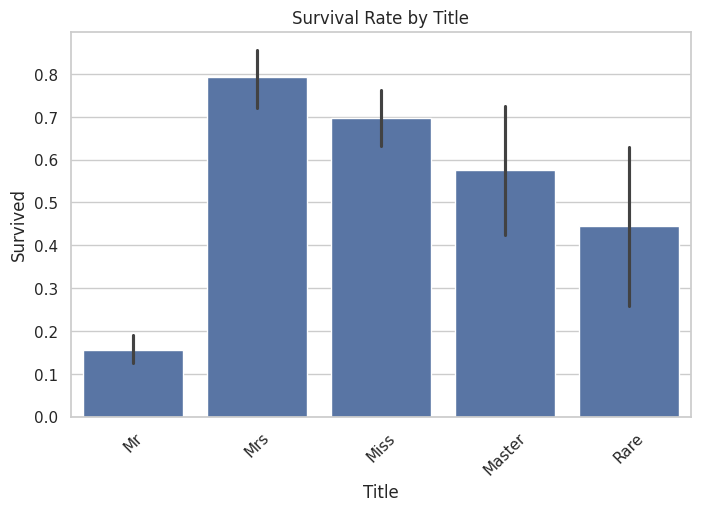

In [27]:
plt.figure(figsize=(8,5))
sns.barplot(x='Title', y='Survived', data=df)
plt.title("Survival Rate by Title")
plt.xticks(rotation=45)
plt.show()

### Observations

- Titles such as Mrs and Miss show significantly higher survival rates.
- The title Mr has the lowest survival rate.
- Rare titles show varied survival outcomes.

## Correlation Analysis

Correlation analysis helps us understand how numerical variables are related to each other.

Examining the correlation between survival and other numerical features such as:

- Age
- Fare
- Pclass
- FamilySize
- IsAlone

This helps identify which features may have stronger influence on survival.

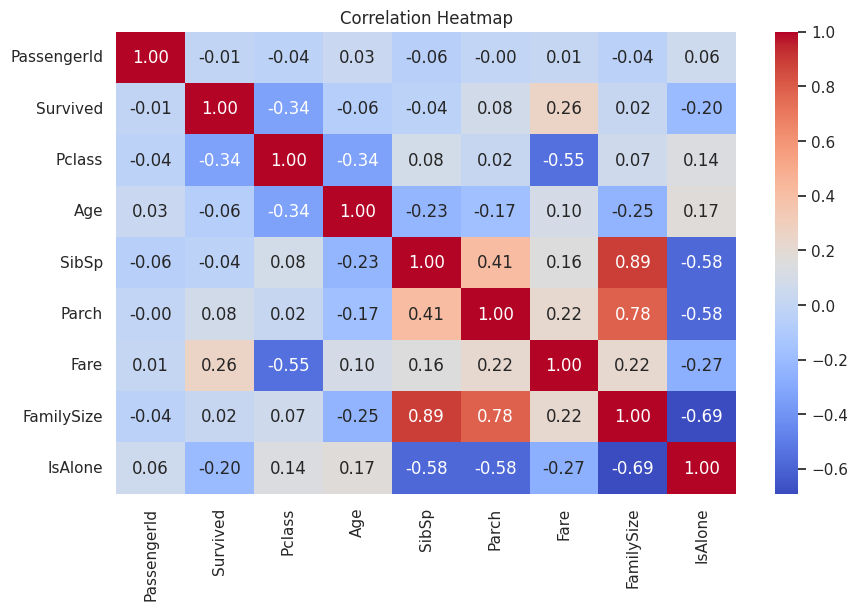

In [28]:
# Selecting only numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

### Observations

- Survival shows negative correlation with Pclass (higher class number, lower survival).
- Fare shows positive correlation with survival.
- FamilySize and IsAlone show mild relationships with survival.
- Age does not show a strong linear correlation with survival.

This indicates that gender and passenger class were stronger predictors than age alone.

In [29]:
# Check number of zero Fare values
print("Number of zero Fare values:", (df['Fare'] == 0).sum())

# Replace zero Fare with median Fare of corresponding Pclass
df.loc[df['Fare'] == 0, 'Fare'] = df.groupby('Pclass')['Fare'].transform('median')
print("Number of zero Fare values after correction:", (df['Fare'] == 0).sum())

Number of zero Fare values: 15
Number of zero Fare values after correction: 0


In [30]:
# Ticket number is not very useful for prediction
df = df.drop(columns=['Ticket'], errors='ignore')

## Conclusion

This exploratory data analysis helped uncover meaningful patterns within the Titanic dataset and provided a clearer understanding of the factors that influenced passenger survival. The results show that survival outcomes were closely linked to social, demographic, and economic characteristics.

### Key Findings:

### 1. Primary Factors Influencing Survival

* **Sex and Title:** Survival patterns strongly favored women. Passengers with titles such as *Mrs* and *Miss* had much higher survival rates compared to *Mr*.

* **Passenger Class:** First-class passengers had the highest probability of survival, followed by second class, while third-class passengers faced the greatest risk.

* **Age and Age Groups:** When categorized into age groups, children showed relatively higher survival rates compared to adults and seniors.


### 2. Other Contributing Factors

* **Family Structure:** Passengers traveling in small family groups tended to have better survival outcomes compared to those traveling alone or in very large families.

* **Fare:** Higher ticket fares were associated with increased survival likelihood, reinforcing the connection between economic status and rescue access.

* **Embarkation Port:** Survival rates varied slightly across embarkation locations, potentially due to differences in passenger class distribution.


### Overall Interpretation

The analysis indicates that survival was heavily influenced by gender, socio-economic status, and age-related factors.

In [31]:
!pip install ydata-profiling

In [32]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Titanic Dataset Profiling Report", explorative=True)

# Save report
profile.to_file("titanic_profile_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 14/14 [00:00<00:00, 25.93it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]